In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import pickle
import os
import json
from datetime import datetime
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# ==========================
# DATA LOADING AND PREPROCESSING
# ==========================
def load_and_preprocess_data(file_path):
    """
    Load and preprocess the dataset
    """
    print("LOADING DATASET...")
    df = pd.read_csv(file_path)

    # Clean column names
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n', ' ')
    df.columns = df.columns.str.replace('  ', ' ')

    print(f"Dataset loaded: {df.shape}")
    return df

def prepare_features(df, target_col='Asylum Seekers'):
    """
    Prepare features for XGBoost model - FIXED to avoid leakage
    """
    df_processed = df.copy()

    print("\nPREPARING FEATURES FOR XGBOOST...")

    # 1. Handle missing values
    print("   Handling missing values...")
    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    for col in numeric_cols:
        if col != target_col and col != 'Country' and col != 'Year':
            # Fill with median by country
            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            )
            # If still missing, fill with overall median
            df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # 2. Encode categorical variables
    print("   Encoding categorical variables...")
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])

    # 3. Create time-based features
    print("   Creating time-based features...")
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()
    df_processed = df_processed.sort_values(['Country', 'Year'])

    # 4. Create lag features for key variables
    print("   Creating lag features...")
    key_vars = [
        'D_Expenditure_GDP',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Refugees'
    ]

    existing_vars = [var for var in key_vars if var in df_processed.columns]

    for var in existing_vars:
        for lag in [1, 2, 3]:
            df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)

    # 5. Create rolling statistics (FIXED to avoid leakage)
    print("   Creating rolling statistics...")
    for var in ['D_Expenditure_GDP']:  # Only for defense, NOT for target!
        if var in df_processed.columns:
            df_processed[f'{var}_Rolling_Mean_3'] = df_processed.groupby('Country')[var].transform(
                lambda x: x.rolling(window=3, min_periods=1).mean()
            )

    # 6. Create interaction features with defense expenditure
    print("   Creating interaction features...")
    if 'D_Expenditure_GDP' in df_processed.columns:
        if 'GDP_Current_USDollars' in df_processed.columns:
            df_processed['Defense_GDP_Interaction'] = df_processed['D_Expenditure_GDP'] * np.log1p(df_processed['GDP_Current_USDollars'])
        if 'Conflict_Intensity' in df_processed.columns:
            df_processed['Defense_Conflict_Interaction'] = df_processed['D_Expenditure_GDP'] * df_processed['Conflict_Intensity']
        df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2

    # 7. Fill remaining NaN values
    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    print(f"Final dataset shape: {df_processed.shape}")
    return df_processed, le_country

# ==========================
# XGBOOST ONLY MODEL WITH H5 AND PKL SAVING
# ==========================
class XGBoostOnlyModel:
    """
    ONLY XGBoost model for asylum prediction with .h5 and .pkl saving
    """
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.r2_score = None
        self.mae = None
        self.rmse = None
        self.training_date = None

    def get_features(self, df, feature_set='Full_Model'):
        """
        Get features for XGBoost model
        """
        base_features = [
            'Year_Scaled',
            'Country_Encoded',
            'D_Expenditure_GDP',
        ]

        defense_features = [
            'D_Expenditure_GDP_Lag_1',
            'D_Expenditure_GDP_Lag_2',
            'D_Expenditure_GDP_Rolling_Mean_3',
            'Defense_Squared',
        ]

        economic_features = [
            'GDP_Current_USDollars',
            'GDP_Growth_Annual',
            'Inflation_Annual',
            'Unemployment_Total_of_TLF',
        ]

        migration_features = [
            'Refugees',
            'Refugees_Lag_1',
            'Asylum Seekers_Lag_1',
            'Asylum Seekers_Lag_2',
        ]

        # Add interaction features if they exist
        interaction_features = []
        if 'Defense_GDP_Interaction' in df.columns:
            interaction_features.append('Defense_GDP_Interaction')
        if 'Defense_Conflict_Interaction' in df.columns:
            interaction_features.append('Defense_Conflict_Interaction')

        # Choose feature set
        if feature_set == 'Defense_Only':
            all_features = base_features + defense_features + interaction_features
        elif feature_set == 'Defense_Economic':
            all_features = base_features + defense_features + economic_features + interaction_features
        elif feature_set == 'Defense_Migration':
            all_features = base_features + defense_features + migration_features + interaction_features
        else:  # Full_Model
            all_features = (base_features + defense_features + economic_features +
                          migration_features + interaction_features)

        # Remove duplicates and filter to existing columns
        all_features = list(set(all_features))
        available_features = [f for f in all_features if f in df.columns]

        print(f"\nXGBOOST FEATURES ({len(available_features)} total)")
        return available_features

    def train(self, df, feature_set='Full_Model', target_col='Asylum Seekers',
              test_years=[2020, 2021, 2022, 2023, 2024]):
        """
        Train XGBoost model
        """
        print("\n" + "="*60)
        print(f"TRAINING XGBOOST - {feature_set}")
        print("="*60)

        # Get features
        self.feature_names = self.get_features(df, feature_set)

        # Prepare data
        X = df[self.feature_names]
        y = df[target_col]

        # Split by time
        train_mask = ~df['Year'].isin(test_years)
        test_mask = df['Year'].isin(test_years)

        X_train = X[train_mask]
        X_test = X[test_mask]
        y_train = y[train_mask]
        y_test = y[test_mask]

        print(f"\nData Split: {len(X_train)} training, {len(X_test)} testing")

        # Scale features
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        # Train XGBoost model
        print("\nTraining XGBoost...")
        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            min_child_weight=2,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1
        )

        self.model.fit(X_train_scaled, y_train)

        # Create native booster for saving
        self.booster = self.model.get_booster()
        self.training_date = datetime.now()

        print("Training complete!")

        # Evaluate
        self.evaluate(X_test_scaled, y_test)

        return self.model

    def evaluate(self, X_test, y_test):
        """Evaluate model performance"""
        y_pred = self.model.predict(X_test)

        # Overall metrics
        self.r2_score = r2_score(y_test, y_pred)
        self.mae = mean_absolute_error(y_test, y_pred)
        self.rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        print(f"\nXGBoost Performance:")
        print(f"  R2 Score:  {self.r2_score:.4f} ({self.r2_score*100:.1f}% accuracy)")
        print(f"  MAE:       {self.mae:,.2f} asylum seekers")
        print(f"  RMSE:      {self.rmse:,.2f} asylum seekers")

    # ==========================
    # H5 SAVING FUNCTION
    # ==========================
    def save_to_h5(self, filename='xgboost_asylum_model.h5'):
        """
        Save XGBoost model to .h5 format
        """
        print("\n" + "="*60)
        print("SAVING XGBOOST MODEL TO .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'w') as f:

            # 1. Save metadata
            f.attrs['model_type'] = 'XGBoost Asylum Predictor'
            f.attrs['r2_score'] = self.r2_score if self.r2_score else 0.0
            f.attrs['mae'] = self.mae if self.mae else 0.0
            f.attrs['rmse'] = self.rmse if self.rmse else 0.0
            f.attrs['n_features'] = len(self.feature_names) if self.feature_names else 0
            f.attrs['created_date'] = str(self.training_date)

            # 2. Save XGBoost model (as bytes)
            model_bytes = self.booster.save_raw()
            f.create_dataset('model_bytes', data=np.frombuffer(model_bytes, dtype='uint8'))

            # 3. Save feature names
            if self.feature_names:
                dt = h5py.string_dtype(encoding='utf-8')
                f.create_dataset('feature_names',
                               data=np.array(self.feature_names, dtype=object).astype('S'),
                               dtype=dt)

            # 4. Save scaler parameters
            if self.scaler:
                f.create_dataset('scaler_mean', data=self.scaler.mean_)
                f.create_dataset('scaler_scale', data=self.scaler.scale_)
                if hasattr(self.scaler, 'var_'):
                    f.create_dataset('scaler_var', data=self.scaler.var_)

            # 5. Save country mapping
            if self.le_country:
                country_group = f.create_group('country_mapping')
                dt = h5py.string_dtype(encoding='utf-8')
                country_data = np.array(list(self.le_country.classes_), dtype=object).astype('S')
                country_group.create_dataset('countries', data=country_data, dtype=dt)
                country_group.create_dataset('country_codes', data=self.le_country.transform(self.le_country.classes_))

            # 6. Save model configuration
            config_group = f.create_group('config')
            config = self.model.get_xgb_params()
            for key, value in config.items():
                if isinstance(value, (int, float, str, bool)):
                    config_group.attrs[key] = str(value)

        file_size = os.path.getsize(filename) / 1024
        print(f"XGBoost model saved to: {filename}")
        print(f"File size: {file_size:.2f} KB")
        print(f"R2 Score: {self.r2_score:.4f}")

        return filename

    # ==========================
    # PKL SAVING FUNCTION
    # ==========================
    def save_to_pkl(self, filename='xgboost_asylum_model.pkl'):
        """
        Save XGBoost model to .pkl format
        """
        print("\n" + "="*60)
        print("SAVING XGBOOST MODEL TO .pkl FORMAT")
        print("="*60)

        # Create a dictionary with all model components
        model_data = {
            'model': self.model,
            'booster': self.booster,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'country_mapping': dict(zip(self.le_country.classes_, self.le_country.transform(self.le_country.classes_))) if self.le_country else None,
            'metrics': {
                'r2_score': self.r2_score,
                'mae': self.mae,
                'rmse': self.rmse
            },
            'training_date': self.training_date,
            'model_type': 'XGBoost Asylum Predictor',
            'model_params': self.model.get_xgb_params() if self.model else None
        }

        # Save using pickle
        with open(filename, 'wb') as f:
            pickle.dump(model_data, f)

        file_size = os.path.getsize(filename) / 1024
        print(f"XGBoost model saved to: {filename}")
        print(f"File size: {file_size:.2f} KB")

        return filename

    # ==========================
    # SAVE ALL FORMATS
    # ==========================
    def save_all_formats(self, base_filename='xgboost_asylum_model'):
        """
        Save model in both .h5 and .pkl formats
        """
        print("\n" + "="*60)
        print("SAVING MODEL IN ALL FORMATS")
        print("="*60)

        saved_files = []

        # Save .h5
        h5_file = self.save_to_h5(f"{base_filename}.h5")
        saved_files.append(h5_file)

        # Save .pkl
        pkl_file = self.save_to_pkl(f"{base_filename}.pkl")
        saved_files.append(pkl_file)

        print(f"\nAll formats saved successfully!")
        print(f"Files created:")
        for f in saved_files:
            print(f"  • {f}")

        return saved_files

    # ==========================
    # LOAD FROM PKL
    # ==========================
    def load_from_pkl(self, filename):
        """
        Load XGBoost model from .pkl format
        """
        print("\n" + "="*60)
        print("LOADING XGBOOST MODEL FROM .pkl FORMAT")
        print("="*60)

        with open(filename, 'rb') as f:
            model_data = pickle.load(f)

        self.model = model_data['model']
        self.booster = model_data['booster']
        self.scaler = model_data['scaler']
        self.feature_names = model_data['feature_names']
        self.le_country = model_data['le_country']
        self.r2_score = model_data['metrics']['r2_score']
        self.mae = model_data['metrics']['mae']
        self.rmse = model_data['metrics']['rmse']
        self.training_date = model_data['training_date']

        print(f"\nModel Info:")
        print(f"  Type: {model_data['model_type']}")
        print(f"  R2 Score: {self.r2_score:.4f}")
        print(f"  MAE: {self.mae:,.2f}")
        print(f"  Training Date: {self.training_date}")

        print(f"XGBoost model loaded from: {filename}")
        return self

    # ==========================
    # LOAD FROM H5
    # ==========================
    def load_from_h5(self, filename):
        """
        Load XGBoost model from .h5 format
        """
        print("\n" + "="*60)
        print("LOADING XGBOOST MODEL FROM .h5 FORMAT")
        print("="*60)

        with h5py.File(filename, 'r') as f:

            # Load metadata
            print(f"\nModel Info:")
            print(f"  Type: {f.attrs['model_type']}")
            print(f"  R2 Score: {f.attrs['r2_score']:.4f}")
            print(f"  MAE: {f.attrs['mae']:,.2f}")
            print(f"  Features: {f.attrs['n_features']}")
            print(f"  Created: {f.attrs['created_date']}")

            # Load XGBoost model
            model_bytes = f['model_bytes'][:].tobytes()
            self.booster = xgb.Booster()
            self.booster.load_raw(model_bytes)

            # Recreate XGBoost regressor
            self.model = XGBRegressor()
            self.model._Booster = self.booster

            # Load feature names
            if 'feature_names' in f:
                feature_names = f['feature_names'][:]
                self.feature_names = [name.decode('utf-8') if isinstance(name, bytes) else name
                                     for name in feature_names]

            # Load scaler
            if 'scaler_mean' in f and 'scaler_scale' in f:
                self.scaler = StandardScaler()
                self.scaler.mean_ = f['scaler_mean'][:]
                self.scaler.scale_ = f['scaler_scale'][:]
                if 'scaler_var' in f:
                    self.scaler.var_ = f['scaler_var'][:]

            # Load metrics
            self.r2_score = f.attrs.get('r2_score', None)
            self.mae = f.attrs.get('mae', None)
            self.rmse = f.attrs.get('rmse', None)

        print(f"XGBoost model loaded from: {filename}")
        return self

    def predict(self, X):
        """
        Make predictions using the loaded model
        """
        if self.model is None:
            print("No model loaded!")
            return None

        # Scale features
        X_scaled = self.scaler.transform(X)

        # Predict
        predictions = self.model.predict(X_scaled)

        return predictions

# ==========================
# MAIN EXECUTION
# ==========================
def main():
    print("="*60)
    print("XGBOOST ONLY - ASYLUM MODEL WITH H5 AND PKL SAVING")
    print("="*60)

    # Load data
    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'
    df = load_and_preprocess_data(file_path)

    # Prepare features
    df_processed, le_country = prepare_features(df)

    # Create XGBoost model
    model = XGBoostOnlyModel()
    model.le_country = le_country

    # Train on Full Model
    model.train(df_processed, feature_set='Full_Model', target_col='Asylum Seekers')

    # Save to both H5 and PKL
    saved_files = model.save_all_formats('xgboost_asylum_model')

    print(f"\n{'='*60}")
    print("ANALYSIS COMPLETE!")
    print('='*60)

    # Show file locations
    print(f"\nFiles saved at: {os.getcwd()}")
    for file in saved_files:
        if os.path.exists(file):
            print(f"\nFile: {file}")
            print(f"  Path: {os.path.abspath(file)}")
            print(f"  Size: {os.path.getsize(file) / 1024:.2f} KB")

    print("\nTO USE THE MODEL LATER:")
    print("\n  # Method 1: Load from .h5")
    print("  from xgboost_model import XGBoostOnlyModel")
    print("  model = XGBoostOnlyModel()")
    print("  model.load_from_h5('xgboost_asylum_model.h5')")
    print("  predictions = model.predict(X_new)")

    print("\n  # Method 2: Load from .pkl")
    print("  import pickle")
    print("  with open('xgboost_asylum_model.pkl', 'rb') as f:")
    print("      model_data = pickle.load(f)")
    print("      model = model_data['model']")
    print("      scaler = model_data['scaler']")

    # Optional: Download in Colab
    try:
        from google.colab import files
        print("\nDownloading files to your computer...")
        for file in saved_files:
            files.download(file)
    except:
        pass

    return model, saved_files

# Run the model
if __name__ == "__main__":
    model, saved_files = main()

XGBOOST ONLY - ASYLUM MODEL WITH H5 AND PKL SAVING
LOADING DATASET...
Dataset loaded: (155, 27)

PREPARING FEATURES FOR XGBOOST...
   Handling missing values...
   Encoding categorical variables...
   Creating time-based features...
   Creating lag features...
   Creating rolling statistics...
   Creating interaction features...
Final dataset shape: (155, 48)

TRAINING XGBOOST - Full_Model

XGBOOST FEATURES (17 total)

Data Split: 130 training, 25 testing

Training XGBoost...
Training complete!

XGBoost Performance:
  R2 Score:  0.7008 (70.1% accuracy)
  MAE:       17,210.90 asylum seekers
  RMSE:      31,379.53 asylum seekers

SAVING MODEL IN ALL FORMATS

SAVING XGBOOST MODEL TO .h5 FORMAT
XGBoost model saved to: xgboost_asylum_model.h5
File size: 390.18 KB
R2 Score: 0.7008

SAVING XGBOOST MODEL TO .pkl FORMAT
XGBoost model saved to: xgboost_asylum_model.pkl
File size: 383.54 KB

All formats saved successfully!
Files created:
  • xgboost_asylum_model.h5
  • xgboost_asylum_model.pkl

A

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **TESTING CLUSTERS**


LOADING DATASET...
Dataset loaded: (155, 27)

TRAINING MODEL...

MODEL PERFORMANCE
----------------------------
R² Score : 0.9088
MAE      : 4202.28
RMSE     : 12672.29

Model training complete!


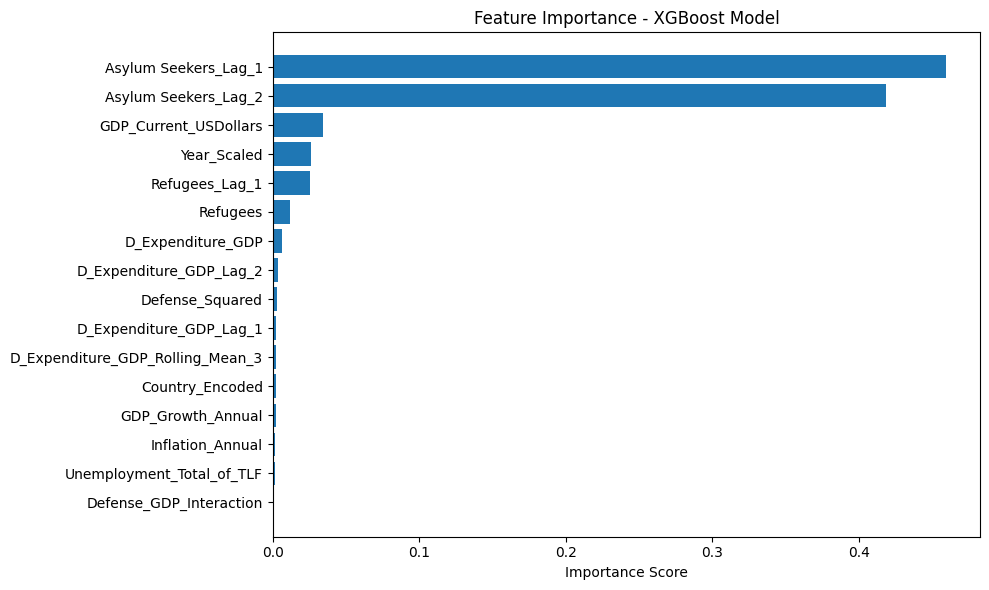


Model saved to xgboost_asylum_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================
# IMPORTS
# ============================================
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')


# ============================================
# DATA LOADING
# ============================================
def load_and_preprocess_data(file_path):

    print("LOADING DATASET...")

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace('\n',' ')
    df.columns = df.columns.str.replace('  ',' ')

    print(f"Dataset loaded: {df.shape}")

    return df


# ============================================
# FEATURE ENGINEERING
# ============================================
def prepare_features(df, target_col='Asylum Seekers'):

    df_processed = df.copy()

    numeric_cols = df_processed.select_dtypes(include=[np.number]).columns

    # Fill missing values
    for col in numeric_cols:

        if col != target_col and col != 'Country' and col != 'Year':

            df_processed[col] = df_processed.groupby('Country')[col].transform(
                lambda x: x.fillna(x.median())
            ).fillna(df_processed[col].median())


    # Encode country
    le_country = LabelEncoder()
    df_processed['Country_Encoded'] = le_country.fit_transform(df_processed['Country'])


    # Year scaling
    df_processed['Year_Scaled'] = df_processed['Year'] - df_processed['Year'].min()

    df_processed = df_processed.sort_values(['Country','Year'])


    # ============================================
    # LAG FEATURES
    # ============================================

    key_vars = [
        'D_Expenditure_GDP',
        'Asylum Seekers',
        'GDP_Current_USDollars',
        'Population',
        'Refugees'
    ]

    for var in key_vars:

        if var in df_processed.columns:

            for lag in [1,2,3]:

                df_processed[f'{var}_Lag_{lag}'] = df_processed.groupby('Country')[var].shift(lag)


    # ============================================
    # ROLLING FEATURES
    # ============================================

    if 'D_Expenditure_GDP' in df_processed.columns:

        df_processed['D_Expenditure_GDP_Rolling_Mean_3'] = df_processed.groupby('Country')[
            'D_Expenditure_GDP'
        ].transform(lambda x: x.rolling(3, min_periods=1).mean())


        if 'GDP_Current_USDollars' in df_processed.columns:

            df_processed['Defense_GDP_Interaction'] = (
                df_processed['D_Expenditure_GDP'] *
                np.log1p(df_processed['GDP_Current_USDollars'])
            )

            df_processed['Defense_Squared'] = df_processed['D_Expenditure_GDP'] ** 2


    df_processed = df_processed.fillna(method='bfill').fillna(method='ffill').fillna(0)

    return df_processed, le_country


# ============================================
# MODEL CLASS
# ============================================
class AsylumPredictor:

    def __init__(self):

        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.historical_data = None

        self.r2_score = None
        self.mae = None
        self.rmse = None

        self.training_date = datetime.now().strftime('%Y-%m-%d %H:%M:%S')


    # ============================================
    # TRAIN MODEL
    # ============================================
    def train(self, df, target_col='Asylum Seekers'):

        print("\nTRAINING MODEL...")

        self.historical_data = df.copy()

        self.le_country = LabelEncoder()
        df['Country_Encoded'] = self.le_country.fit_transform(df['Country'])


        self.feature_names = [

            'Year_Scaled',
            'Country_Encoded',
            'D_Expenditure_GDP',

            'D_Expenditure_GDP_Lag_1',
            'D_Expenditure_GDP_Lag_2',
            'D_Expenditure_GDP_Rolling_Mean_3',

            'Defense_Squared',

            'GDP_Current_USDollars',
            'GDP_Growth_Annual',
            'Inflation_Annual',

            'Unemployment_Total_of_TLF',

            'Refugees',
            'Refugees_Lag_1',

            'Asylum Seekers_Lag_1',
            'Asylum Seekers_Lag_2',

            'Defense_GDP_Interaction'

        ]

        self.feature_names = [f for f in self.feature_names if f in df.columns]

        X = df[self.feature_names]
        y = df[target_col]


        # Train Test Split
        X_train, X_test, y_train, y_test = train_test_split(
            X, y,
            test_size=0.2,
            random_state=42
        )


        # Scale
        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)


        # Model
        self.model = XGBRegressor(

            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,

            min_child_weight=2,

            subsample=0.8,
            colsample_bytree=0.8,

            reg_alpha=0.1,
            reg_lambda=1.0,

            random_state=42,
            n_jobs=-1
        )


        # Train
        self.model.fit(X_train_scaled, y_train)


        # Predictions
        y_pred = self.model.predict(X_test_scaled)


        # ============================================
        # MODEL PERFORMANCE
        # ============================================

        self.r2_score = r2_score(y_test, y_pred)
        self.mae = mean_absolute_error(y_test, y_pred)
        self.rmse = np.sqrt(mean_squared_error(y_test, y_pred))


        print("\nMODEL PERFORMANCE")
        print("----------------------------")
        print(f"R² Score : {self.r2_score:.4f}")
        print(f"MAE      : {self.mae:.2f}")
        print(f"RMSE     : {self.rmse:.2f}")

        print("\nModel training complete!")

        self.plot_feature_importance()


    # ============================================
    # FEATURE IMPORTANCE GRAPH
    # ============================================
    def plot_feature_importance(self):

        importance = self.model.feature_importances_

        feat_imp = pd.DataFrame({

            'Feature': self.feature_names,
            'Importance': importance

        }).sort_values(by='Importance', ascending=False)


        plt.figure(figsize=(10,6))

        plt.barh(
            feat_imp['Feature'],
            feat_imp['Importance']
        )

        plt.gca().invert_yaxis()

        plt.title("Feature Importance - XGBoost Model")
        plt.xlabel("Importance Score")

        plt.tight_layout()

        plt.show()


    # ============================================
    # SAVE MODEL
    # ============================================
    def save_to_pkl(self, filename='xgboost_asylum_model.pkl'):

        model_data = {

            'model': self.model,
            'scaler': self.scaler,
            'feature_names': self.feature_names,
            'le_country': self.le_country,
            'historical_data': self.historical_data,

            'training_date': self.training_date,

            'r2_score': self.r2_score,
            'mae': self.mae,
            'rmse': self.rmse

        }

        with open(filename,'wb') as f:

            pickle.dump(model_data,f)

        print(f"\nModel saved to {filename}")


# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":

    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'

    df = load_and_preprocess_data(file_path)

    df_processed, le_country = prepare_features(df)

    predictor = AsylumPredictor()

    predictor.train(df_processed)

    # Save model
    predictor.save_to_pkl('xgboost_asylum_model.pkl')

    # ============================================
    # DOWNLOAD MODEL TO LAPTOP
    # ============================================
    from google.colab import files

    files.download('xgboost_asylum_model.pkl')

In [ ]:
# ============================================
# LOAD TRAINED MODEL
# ============================================

import pandas as pd
import numpy as np
import pickle

print("Loading trained model...")

with open("xgboost_asylum_model.pkl", "rb") as f:
    model_data = pickle.load(f)

model = model_data["model"]
scaler = model_data["scaler"]
feature_names = model_data["feature_names"]
le_country = model_data["le_country"]
historical_data = model_data["historical_data"]

print("Model loaded successfully")


# ============================================
# RECURSIVE PREDICTION FUNCTION
# ============================================

def predict_future(country, start_year, end_year, defense_value):

    df_hist = historical_data[
        historical_data["Country"] == country
    ].sort_values("Year").copy()

    results = []

    for year in range(start_year, end_year + 1):

        row = {}

        row["Year_Scaled"] = year - historical_data["Year"].min()
        row["Country_Encoded"] = le_country.transform([country])[0]

        row["D_Expenditure_GDP"] = defense_value
        row["D_Expenditure_GDP_Lag_1"] = df_hist["D_Expenditure_GDP"].iloc[-1]
        row["D_Expenditure_GDP_Lag_2"] = df_hist["D_Expenditure_GDP"].iloc[-2]

        row["D_Expenditure_GDP_Rolling_Mean_3"] = df_hist["D_Expenditure_GDP"].tail(3).mean()

        row["Defense_Squared"] = defense_value ** 2

        # Economic variables
        for feat in [
            "GDP_Current_USDollars",
            "GDP_Growth_Annual",
            "Inflation_Annual",
            "Unemployment_Total_of_TLF",
            "Refugees"
        ]:

            if feat in df_hist.columns:
                row[feat] = df_hist[feat].iloc[-1]


        row["Refugees_Lag_1"] = df_hist["Refugees"].iloc[-1]

        row["Asylum Seekers_Lag_1"] = df_hist["Asylum Seekers"].iloc[-1]
        row["Asylum Seekers_Lag_2"] = df_hist["Asylum Seekers"].iloc[-2]

        row["Defense_GDP_Interaction"] = defense_value * np.log1p(
            row.get("GDP_Current_USDollars", 1)
        )


        X_pred = pd.DataFrame(
            [[row.get(f, 0) for f in feature_names]],
            columns=feature_names
        )

        X_scaled = scaler.transform(X_pred)

        pred = float(model.predict(X_scaled)[0])


        results.append({
            "Country": country,
            "Year": year,
            "Defense_GDP": defense_value,
            "Predicted_Asylum": pred,
            "Defense_Scenario": defense_value
        })


        # Update history for next year's lags
        new_row = df_hist.iloc[-1].copy()

        new_row["Year"] = year
        new_row["D_Expenditure_GDP"] = defense_value
        new_row["Asylum Seekers"] = pred

        df_hist = pd.concat([df_hist, pd.DataFrame([new_row])])

    return pd.DataFrame(results)


# ============================================
# RUN PREDICTIONS FOR ALL COUNTRIES
# ============================================

countries = historical_data["Country"].unique()

start_year = 2025
end_year = 2029

# Defense scenarios
defense_scenarios = [2.5, 3.0, 4.0, 5.0]

all_predictions = []

print("Running multi-country predictions...\n")

for country in countries:

    for defense in defense_scenarios:

        preds = predict_future(country, start_year, end_year, defense)

        all_predictions.append(preds)


final_predictions = pd.concat(all_predictions)

# ============================================
# SAVE RESULTS
# ============================================

output_file = "multi_year_asylum_predictions.csv"

final_predictions.to_csv(output_file, index=False)

print(f"\nPredictions saved to {output_file}\n")

print(final_predictions.head(20))

Loading trained model...
Model loaded successfully
Running multi-country predictions...


Predictions saved to multi_year_asylum_predictions.csv

  Country  Year  Defense_GDP  Predicted_Asylum  Defense_Scenario
0     CHN  2025          2.5     117002.234375               2.5
1     CHN  2026          2.5     115925.289062               2.5
2     CHN  2027          2.5     116050.937500               2.5
3     CHN  2028          2.5     116050.937500               2.5
4     CHN  2029          2.5     116050.937500               2.5
0     CHN  2025          3.0     117002.234375               3.0
1     CHN  2026          3.0     115925.289062               3.0
2     CHN  2027          3.0     116050.937500               3.0
3     CHN  2028          3.0     116050.937500               3.0
4     CHN  2029          3.0     116050.937500               3.0
0     CHN  2025          4.0     117016.914062               4.0
1     CHN  2026          4.0     115695.531250               4.0
2     CHN

In [ ]:
# ============================================
# ASYLUM PREDICTION - LOAD .pkl AND PREDICT
# ONLY NEEDS COUNTRY, YEAR, DEFENSE GDP
# ============================================

# Step 1: Upload your .pkl file
from google.colab import files
uploaded = files.upload()  # Upload xgboost_asylum_model.pkl

# Step 2: Import libraries
import pickle
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

# ============================================
# ASYLUM PREDICTOR CLASS (Simplified)
# ============================================
class AsylumPredictor:
    """
    Simple class to load XGBoost asylum model and make predictions
    ONLY NEEDS COUNTRY, YEAR, DEFENSE GDP as input!
    """
    def __init__(self):
        self.model = None
        self.booster = None
        self.scaler = None
        self.feature_names = None
        self.le_country = None
        self.historical_data = None
        self.country_stats = None
        self.r2_score = None
        self.mae = None

    def load_from_pkl(self, filename):
        """Load XGBoost model from .pkl file"""
        print(f"Loading asylum model from {filename}...")

        with open(filename, 'rb') as f:
            data = pickle.load(f)

        self.model = data['model']
        self.booster = data['booster']
        self.scaler = data['scaler']
        self.feature_names = data['feature_names']
        self.le_country = data['le_country']
        self.historical_data = data.get('historical_data', None)
        self.country_stats = data.get('country_stats', {})
        self.r2_score = data['metrics']['r2_score']
        self.mae = data['metrics']['mae']

        print(f" Model loaded successfully!")
        print(f" R² Score: {self.r2_score:.4f}")
        print(f" MAE: {self.mae:,.2f}")
        print(f" Available countries: {list(self.le_country.classes_)}")
        print(f" Historical data available: {self.historical_data is not None}")

        return self

    def predict_asylum(self, country, year, defense_gdp):
        """
        Predict asylum seekers using ONLY country, year, and defense_gdp
        NO CONFLICT INTENSITY NEEDED!
        """
        if self.model is None:
            print(" Model not loaded!")
            return None

        if self.historical_data is None:
            print(" No historical data available for lag calculation!")
            return None

        # Get historical data for this country
        country_history = self.historical_data[
            self.historical_data['Country'] == country
        ].sort_values('Year')

        if len(country_history) == 0:
            print(f" No historical data for {country}")
            return None

        print(f"\n Predicting asylum seekers for {country} - {year}...")

        # Create prediction row
        pred_row = {}

        # 1. Base features
        pred_row['Year_Scaled'] = year - self.historical_data['Year'].min()
        pred_row['Country_Encoded'] = self.le_country.transform([country])[0]

        # 2. Defense features
        pred_row['D_Expenditure_GDP'] = defense_gdp
        pred_row['D_Expenditure_GDP_Lag_1'] = country_history['D_Expenditure_GDP'].iloc[-1]
        pred_row['D_Expenditure_GDP_Lag_2'] = country_history['D_Expenditure_GDP'].iloc[-2] if len(country_history) > 1 else defense_gdp
        pred_row['D_Expenditure_GDP_Rolling_Mean_3'] = country_history['D_Expenditure_GDP'].tail(3).mean()
        pred_row['Defense_Squared'] = defense_gdp ** 2

        # 3. Economic features (latest values)
        for feat in ['GDP_Current_USDollars', 'GDP_Growth_Annual', 'Inflation_Annual', 'Unemployment_Total_of_TLF']:
            if feat in self.feature_names and feat in country_history.columns:
                pred_row[feat] = country_history[feat].iloc[-1]

        # 4. Asylum features (target variable lags)
        if 'Asylum Seekers' in self.feature_names:
            pred_row['Asylum Seekers'] = country_history['Asylum Seekers'].iloc[-1]
            pred_row['Asylum Seekers_Lag_1'] = country_history['Asylum Seekers'].iloc[-1]
            pred_row['Asylum Seekers_Lag_2'] = country_history['Asylum Seekers'].iloc[-2] if len(country_history) > 1 else 0

        # 5. Population features
        if 'Population' in self.feature_names:
            pred_row['Population'] = country_history['Population'].iloc[-1]
            pred_row['Population_Lag_1'] = country_history['Population'].iloc[-1]

        # 6. Refugees features
        if 'Refugees' in self.feature_names:
            pred_row['Refugees'] = country_history['Refugees'].iloc[-1]
            pred_row['Refugees_Lag_1'] = country_history['Refugees'].iloc[-1]

        # 7. Interaction features (without conflict)
        if 'Defense_GDP_Interaction' in self.feature_names:
            pred_row['Defense_GDP_Interaction'] = defense_gdp * np.log1p(pred_row.get('GDP_Current_USDollars', 1))

        # 8. Fill any remaining features with 0
        X_pred = pd.DataFrame(
            [[pred_row.get(feat, 0) for feat in self.feature_names]],
            columns=self.feature_names
        )

        # Scale and predict
        X_pred_scaled = self.scaler.transform(X_pred)
        prediction = self.model.predict(X_pred_scaled)[0]

        # Convert to float for formatting
        if isinstance(prediction, np.ndarray):
            prediction = float(prediction)

        print(f" Predicted asylum seekers: {prediction:,.0f}")

        return prediction

    def get_available_countries(self):
        """Get list of countries the model was trained on"""
        return list(self.le_country.classes_)

    def get_country_stats(self, country):
        """Get basic statistics for a country"""
        if self.historical_data is not None:
            country_data = self.historical_data[self.historical_data['Country'] == country]
            if len(country_data) > 0:
                return {
                    'last_year': int(country_data['Year'].max()),
                    'last_asylum': int(country_data['Asylum Seekers'].iloc[-1]) if 'Asylum Seekers' in country_data.columns else None,
                    'avg_asylum': int(country_data['Asylum Seekers'].mean()) if 'Asylum Seekers' in country_data.columns else None,
                    'data_points': len(country_data)
                }
        return None

# ============================================
# LOAD THE MODEL
# ============================================
print("="*60)
print(" LOADING ASYLUM PREDICTION MODEL")
print("="*60)

predictor = AsylumPredictor()
predictor.load_from_pkl('xgboost_asylum_model.pkl')

# ============================================
# MAKE PREDICTIONS - ONLY COUNTRY, YEAR, DEFENSE GDP!
# ============================================
print("\n" + "="*60)
print(" MAKE ASYLUM PREDICTIONS")
print("="*60)
print("\n Usage: predictor.predict_asylum('COUNTRY', YEAR, DEFENSE_GDP)")
print(f" Available countries: {predictor.get_available_countries()}")

# Example predictions
print("\n" + "="*60)
print(" EXAMPLE PREDICTIONS")
print("="*60)

test_scenarios = [
    ('FRA', 2025, 2.0),
    ('FRA', 2025, 3.0),
    ('FRA', 2025, 4.0),
    ('GBR', 2025, 2.2),
    ('GBR', 2025, 3.5),
    ('RUS', 2025, 3.0),
    ('RUS', 2025, 4.0),
    ('RUS', 2025, 5.0),
    ('USA', 2025, 3.0),
    ('USA', 2025, 4.5),
    ('CHN', 2025, 1.8),
    ('CHN', 2025, 2.5),
]

results = []
for country, year, defense in test_scenarios:
    pred = predictor.predict_asylum(country, year, defense)
    if pred:
        results.append({
            'Country': country,
            'Year': year,
            'Defense_GDP': defense,
            'Predicted_Asylum': int(pred)
        })
        print(f"{country} | {year} | Defense {defense}% → {int(pred):,}")

# Save results to CSV
if results:
    results_df = pd.DataFrame(results)
    results_df.to_csv('asylum_predictions.csv', index=False)
    print(f"\n Results saved to asylum_predictions.csv")

# ============================================
# SIMPLE FUNCTION FOR QUICK PREDICTIONS
# ============================================
def quick_asylum(country, year, defense_gdp):
    """
    Ultra-simple function for quick asylum predictions
    Usage: quick_asylum('FRA', 2025, 2.5)
    """
    return predictor.predict_asylum(country, year, defense_gdp)

print("\n" + "="*60)
print(" QUICK PREDICTION FUNCTION READY")
print("="*60)
print("\nUsage: quick_asylum('FRA', 2025, 2.5)")
print("Example: quick_asylum('RUS', 2025, 4.0)")

# Test the quick function
print("\n Quick Predictions:")
print(f"France 2025 (2.5%): {quick_asylum('FRA', 2025, 2.5):,.0f}")
print(f"Russia 2025 (4.0%): {quick_asylum('RUS', 2025, 4.0):,.0f}")
print(f"UK 2025 (2.2%): {quick_asylum('GBR', 2025, 2.2):,.0f}")

Saving xgboost_asylum_model (12).pkl to xgboost_asylum_model (12).pkl
 LOADING ASYLUM PREDICTION MODEL
Loading asylum model from xgboost_asylum_model.pkl...


KeyError: 'booster'

# **test3**

In [ ]:
# ============================================
# IMPORTS
# ============================================
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")


# ============================================
# LOAD DATA
# ============================================
def load_and_preprocess_data(file_path):

    print("Loading dataset...")

    df = pd.read_csv(file_path)

    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace("\n", " ")
    df.columns = df.columns.str.replace("  ", " ")

    df["Country"] = df["Country"].astype(str).str.strip()

    print("Dataset shape:", df.shape)

    return df


# ============================================
# FEATURE ENGINEERING
# ============================================
def prepare_features(df):

    df = df.sort_values(["Country", "Year"]).copy()

    # Encode country
    le = LabelEncoder()
    df["Country_Encoded"] = le.fit_transform(df["Country"])

    # Year scaling
    df["Year_Scaled"] = df["Year"] - df["Year"].min()

    # Lag features
    df["D_Expenditure_GDP_Lag_1"] = df.groupby("Country")["D_Expenditure_GDP"].shift(1)
    df["D_Expenditure_GDP_Lag_2"] = df.groupby("Country")["D_Expenditure_GDP"].shift(2)

    df["Asylum Seekers_Lag_1"] = df.groupby("Country")["Asylum Seekers"].shift(1)
    df["Asylum Seekers_Lag_2"] = df.groupby("Country")["Asylum Seekers"].shift(2)

    df["Refugees_Lag_1"] = df.groupby("Country")["Refugees"].shift(1)

    # Rolling mean
    df["D_Expenditure_GDP_Rolling_Mean_3"] = (
        df.groupby("Country")["D_Expenditure_GDP"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

    # Interaction features
    df["Defense_Squared"] = df["D_Expenditure_GDP"] ** 2
    df["Defense_GDP_Interaction"] = (
        df["D_Expenditure_GDP"] * np.log1p(df["GDP_Current_USDollars"])
    )

    df = df.fillna(method="bfill").fillna(method="ffill")

    return df, le


# ============================================
# MODEL CLASS
# ============================================
class AsylumPredictor:

    def __init__(self):

        self.model = None
        self.scaler = StandardScaler()
        self.feature_names = None
        self.le_country = None
        self.historical_data = None


    # ============================================
    # TRAIN MODEL
    # ============================================
    def train(self, df):

        print("\nTraining model...")

        self.historical_data = df.copy()

        self.le_country = LabelEncoder()
        df["Country_Encoded"] = self.le_country.fit_transform(df["Country"])

        self.feature_names = [

            "Year_Scaled",
            "Country_Encoded",
            "D_Expenditure_GDP",

            "D_Expenditure_GDP_Lag_1",
            "D_Expenditure_GDP_Lag_2",

            "D_Expenditure_GDP_Rolling_Mean_3",

            "Defense_Squared",
            "Defense_GDP_Interaction",

            "GDP_Current_USDollars",
            "GDP_Growth_Annual",
            "Inflation_Annual",
            "Unemployment_Total_of_TLF",

            "Refugees",
            "Refugees_Lag_1",

            "Asylum Seekers_Lag_1",
            "Asylum Seekers_Lag_2"
        ]

        self.feature_names = [f for f in self.feature_names if f in df.columns]

        X = df[self.feature_names]
        y = df["Asylum Seekers"]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        X_train_scaled = self.scaler.fit_transform(X_train)
        X_test_scaled = self.scaler.transform(X_test)

        self.model = XGBRegressor(
            n_estimators=300,
            learning_rate=0.03,
            max_depth=5,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42
        )

        self.model.fit(X_train_scaled, y_train)

        y_pred = self.model.predict(X_test_scaled)

        print("\nModel Performance")
        print("------------------")
        print("R2 :", r2_score(y_test, y_pred))
        print("MAE:", mean_absolute_error(y_test, y_pred))
        print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


    # ============================================
    # SAVE MODEL AND DOWNLOAD TO LAPTOP (COLAB)
    # ============================================
    def save_model(self, filename="xgboost_asylum_model.pkl"):

        model_data = {
            "model": self.model,
            "scaler": self.scaler,
            "feature_names": self.feature_names,
            "le_country": self.le_country,
            "historical_data": self.historical_data
        }

        with open(filename, "wb") as f:
            pickle.dump(model_data, f)

        print("\nModel saved:", filename)

        # Download to laptop (for Colab)
        try:
            from google.colab import files
            files.download(filename)
        except:
            pass


    # ============================================
    # RECURSIVE FUTURE PREDICTION
    # ============================================
    def predict_year(self, country, target_year, defense_exp):

        df_hist = self.historical_data.copy()
        df_hist["Country"] = df_hist["Country"].astype(str).str.strip()

        if country not in df_hist["Country"].unique():
            raise ValueError(
                f"Country '{country}' not found. Available countries: {sorted(df_hist['Country'].unique())}"
            )

        country_df = df_hist[df_hist["Country"] == country].sort_values("Year").copy()
        last_year = int(country_df["Year"].dropna().max())

        if target_year <= last_year:
            raise ValueError(
                f"Target year must be greater than last dataset year ({last_year})"
            )

        # Recursive forecast for each year
        for year in range(last_year + 1, target_year + 1):

            country_df = country_df.sort_values("Year")

            country_df["D_Expenditure_GDP_Lag_1"] = country_df["D_Expenditure_GDP"].shift(1)
            country_df["D_Expenditure_GDP_Lag_2"] = country_df["D_Expenditure_GDP"].shift(2)
            country_df["Asylum Seekers_Lag_1"] = country_df["Asylum Seekers"].shift(1)
            country_df["Asylum Seekers_Lag_2"] = country_df["Asylum Seekers"].shift(2)
            country_df["Refugees_Lag_1"] = country_df["Refugees"].shift(1)
            country_df["D_Expenditure_GDP_Rolling_Mean_3"] = (
                country_df["D_Expenditure_GDP"].rolling(3, min_periods=1).mean()
            )

            last_row = country_df.iloc[-1]

            features = {
                "Year_Scaled": year - df_hist["Year"].min(),
                "Country_Encoded": self.le_country.transform([country])[0],
                "D_Expenditure_GDP": defense_exp,
                "D_Expenditure_GDP_Lag_1": last_row["D_Expenditure_GDP"],
                "D_Expenditure_GDP_Lag_2": last_row["D_Expenditure_GDP_Lag_1"],
                "D_Expenditure_GDP_Rolling_Mean_3": country_df["D_Expenditure_GDP"].tail(3).mean(),
                "Defense_Squared": defense_exp ** 2,
                "Defense_GDP_Interaction": defense_exp * np.log1p(last_row["GDP_Current_USDollars"]),
                "GDP_Current_USDollars": last_row["GDP_Current_USDollars"],
                "GDP_Growth_Annual": last_row["GDP_Growth_Annual"],
                "Inflation_Annual": last_row["Inflation_Annual"],
                "Unemployment_Total_of_TLF": last_row["Unemployment_Total_of_TLF"],
                "Refugees": last_row["Refugees"],
                "Refugees_Lag_1": last_row["Refugees"],
                "Asylum Seekers_Lag_1": last_row["Asylum Seekers"],
                "Asylum Seekers_Lag_2": last_row["Asylum Seekers_Lag_1"]
            }

            X = pd.DataFrame([features])
            X = X[self.feature_names]

            X_scaled = self.scaler.transform(X)
            prediction = self.model.predict(X_scaled)[0]

            new_row = last_row.copy()
            new_row["Year"] = year
            new_row["D_Expenditure_GDP"] = defense_exp
            new_row["Asylum Seekers"] = prediction

            country_df = pd.concat([country_df, pd.DataFrame([new_row])], ignore_index=True)

        return prediction


# ============================================
# MAIN EXECUTION
# ============================================
if __name__ == "__main__":

    file_path = '/content/drive/MyDrive/Colab Notebooks/Final_MasterDataset.csv'

    df = load_and_preprocess_data(file_path)

    df_processed, le = prepare_features(df)

    predictor = AsylumPredictor()
    predictor.train(df_processed)
    predictor.save_model()  # automatically downloads in Colab

    # Example prediction
    pred = predictor.predict_year(
        country="USA",
        target_year=2025,
        defense_exp=2.3
    )

    print("\nPredicted asylum seekers in 2025:", int(pred))

Loading dataset...
Dataset shape: (155, 27)

Training model...

Model Performance
------------------
R2 : 0.9149179458618164
MAE: 4038.0263671875
RMSE: 12241.48030264314

Model saved: xgboost_asylum_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Predicted asylum seekers in 2025: 2280


In [ ]:
# ============================================
# UPLOAD MODEL AND PREDICT
# ============================================
import pickle
import pandas as pd
import numpy as np
from google.colab import files

# Upload your .pkl model
uploaded = files.upload()  # This will open a file dialog

# Grab the uploaded filename
filename = list(uploaded.keys())[0]

# Load the model
with open(filename, "rb") as f:
    model_data = pickle.load(f)

# Extract components
model = model_data["model"]
scaler = model_data["scaler"]
feature_names = model_data["feature_names"]
le_country = model_data["le_country"]
historical_data = model_data["historical_data"]

print(f"Model loaded from: {filename}")

# ============================================
# FUNCTION TO PREDICT A YEAR
# ============================================
def predict_asylum(country, target_year, defense_exp):
    df_hist = historical_data.copy()
    df_hist["Country"] = df_hist["Country"].astype(str).str.strip()

    if country not in df_hist["Country"].unique():
        raise ValueError(
            f"Country '{country}' not found. Available countries: {sorted(df_hist['Country'].unique())}"
        )

    country_df = df_hist[df_hist["Country"] == country].sort_values("Year").copy()
    last_year = int(country_df["Year"].dropna().max())

    if target_year <= last_year:
        raise ValueError(
            f"Target year must be greater than last dataset year ({last_year})"
        )

    # Recursive prediction
    for year in range(last_year + 1, target_year + 1):
        country_df = country_df.sort_values("Year")

        country_df["D_Expenditure_GDP_Lag_1"] = country_df["D_Expenditure_GDP"].shift(1)
        country_df["D_Expenditure_GDP_Lag_2"] = country_df["D_Expenditure_GDP"].shift(2)
        country_df["Asylum Seekers_Lag_1"] = country_df["Asylum Seekers"].shift(1)
        country_df["Asylum Seekers_Lag_2"] = country_df["Asylum Seekers"].shift(2)
        country_df["Refugees_Lag_1"] = country_df["Refugees"].shift(1)
        country_df["D_Expenditure_GDP_Rolling_Mean_3"] = (
            country_df["D_Expenditure_GDP"].rolling(3, min_periods=1).mean()
        )

        last_row = country_df.iloc[-1]

        features = {
            "Year_Scaled": year - df_hist["Year"].min(),
            "Country_Encoded": le_country.transform([country])[0],
            "D_Expenditure_GDP": defense_exp,
            "D_Expenditure_GDP_Lag_1": last_row["D_Expenditure_GDP"],
            "D_Expenditure_GDP_Lag_2": last_row["D_Expenditure_GDP_Lag_1"],
            "D_Expenditure_GDP_Rolling_Mean_3": country_df["D_Expenditure_GDP"].tail(3).mean(),
            "Defense_Squared": defense_exp ** 2,
            "Defense_GDP_Interaction": defense_exp * np.log1p(last_row["GDP_Current_USDollars"]),
            "GDP_Current_USDollars": last_row["GDP_Current_USDollars"],
            "GDP_Growth_Annual": last_row["GDP_Growth_Annual"],
            "Inflation_Annual": last_row["Inflation_Annual"],
            "Unemployment_Total_of_TLF": last_row["Unemployment_Total_of_TLF"],
            "Refugees": last_row["Refugees"],
            "Refugees_Lag_1": last_row["Refugees"],
            "Asylum Seekers_Lag_1": last_row["Asylum Seekers"],
            "Asylum Seekers_Lag_2": last_row["Asylum Seekers_Lag_1"]
        }

        X = pd.DataFrame([features])
        X = X[feature_names]
        X_scaled = scaler.transform(X)

        prediction = model.predict(X_scaled)[0]

        new_row = last_row.copy()
        new_row["Year"] = year
        new_row["D_Expenditure_GDP"] = defense_exp
        new_row["Asylum Seekers"] = prediction

        country_df = pd.concat([country_df, pd.DataFrame([new_row])], ignore_index=True)

    return prediction


# ============================================
# BULK PREDICTIONS (2025–2030)
# Defense Expenditure values: 1.5, 3.5, 4.5, 5.0, 12.0
# ============================================

defense_values = [1.5, 3.5, 4.5, 5.0, 8.0, 12.0]
years = list(range(2025, 2031))

results = []

for defense in defense_values:
    for year in years:
        try:
            pred = predict_asylum(country="CHN", target_year=year, defense_exp=defense)
            results.append({
                "Country": "CHN",
                "Year": year,
                "Defense_Exp_GDP": defense,
                "Predicted_Asylum_Seekers": int(pred)
            })
        except Exception as e:
            print(f"Error for {year}, defense {defense}: {e}")

# Convert to dataframe
results_df = pd.DataFrame(results)

print("\nPrediction Results:")
print(results_df)

# Save to CSV
results_df.to_csv("asylum_predictions_2025_2030.csv", index=False)

print("\nSaved results to asylum_predictions_2025_2030.csv")

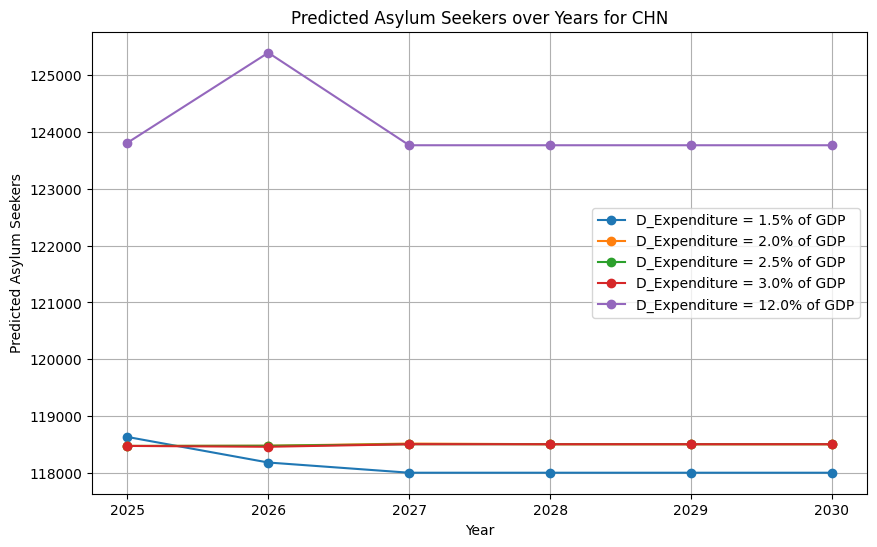

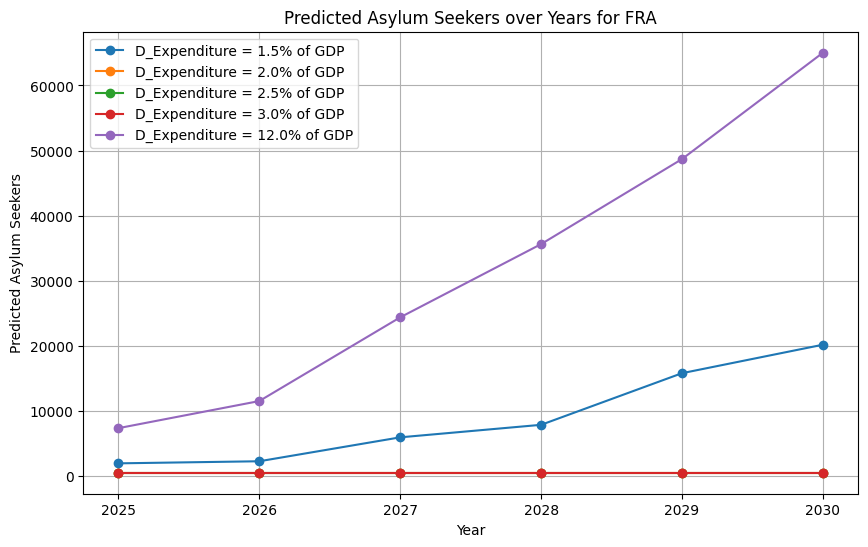

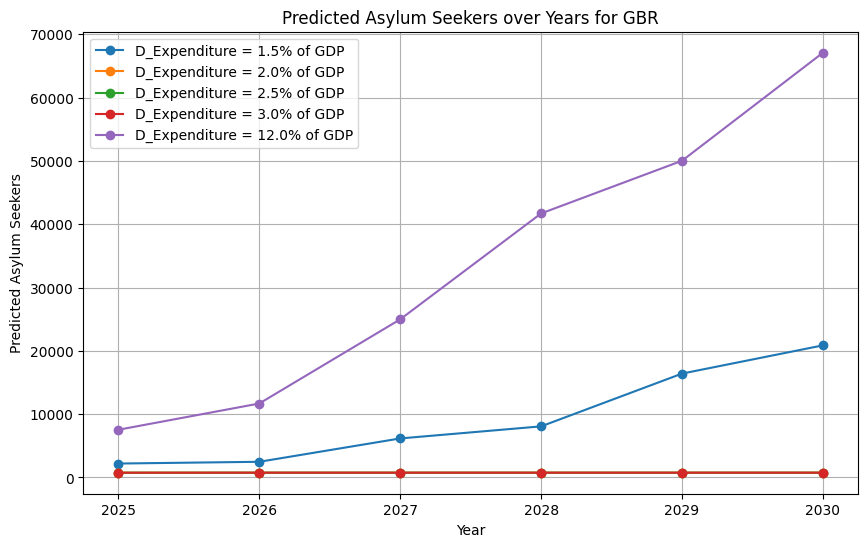

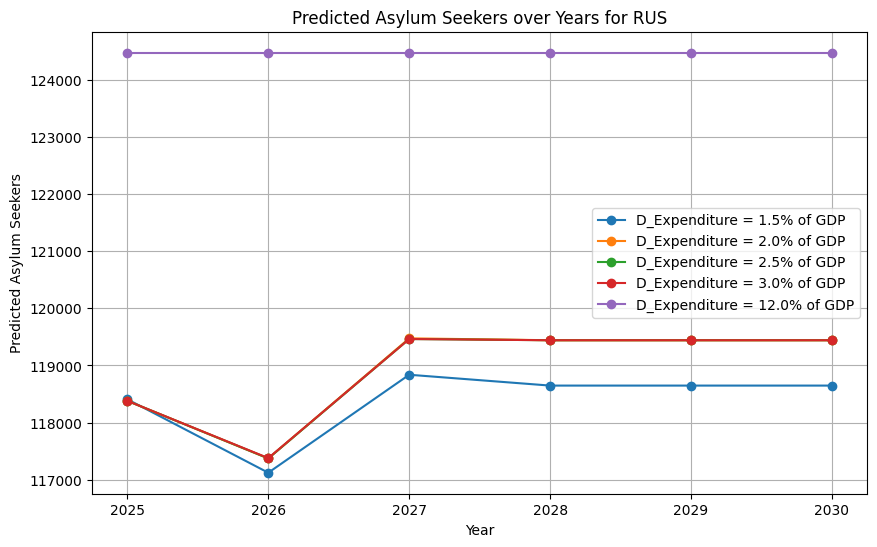

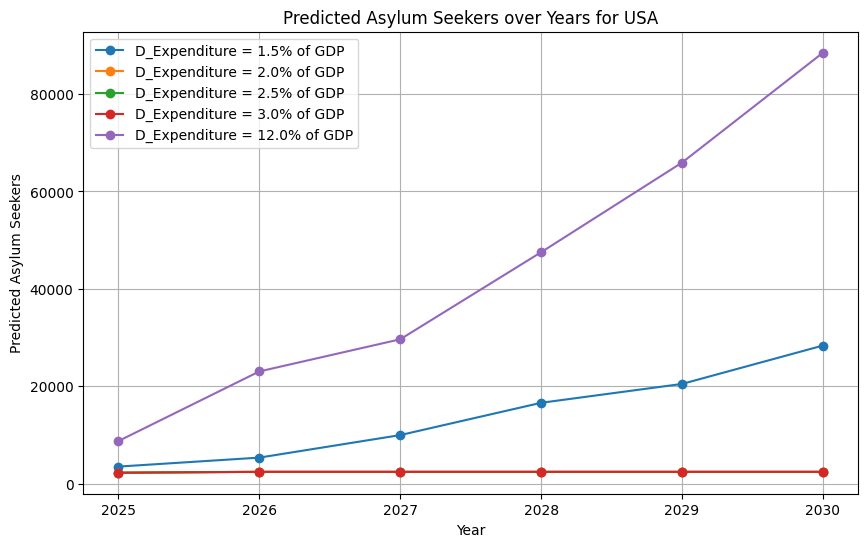

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# PARAMETERS
# ============================================
countries = historical_data["Country"].unique()
future_years = list(range(historical_data["Year"].max() + 1, 2031))  # predict until 2030
gdp_values = [1.5, 2.0, 2.5, 3.0,12.0]  # Example defense expenditure (% of GDP)

# ============================================
# PLOT PREDICTIONS FOR EACH COUNTRY
# ============================================
for country in countries:
    plt.figure(figsize=(10,6))

    for gdp in gdp_values:
        preds = []
        for year in future_years:
            try:
                pred = predict_asylum(country, target_year=year, defense_exp=gdp)
                preds.append(pred)
            except ValueError:
                preds.append(np.nan)

        plt.plot(future_years, preds, marker='o', label=f'D_Expenditure = {gdp}% of GDP')

    plt.title(f"Predicted Asylum Seekers over Years for {country}")
    plt.xlabel("Year")
    plt.ylabel("Predicted Asylum Seekers")
    plt.grid(True)
    plt.legend()
    plt.show()